# Chapter 3: Statistical Experiments and Significance Testing
**Buku:** *Practical Statistics for Data Scientists (2nd Edition)* — Peter Bruce, Andrew Bruce, & Peter Gedeck

---

## 1. Chapter Summary
Desain eksperimen adalah landasan dari praktik statistika untuk mengonfirmasi atau menolak sebuah hipotesis[cite: 13]. Dalam konteks data science, eksperimen berulang kali dilakukan untuk menguji antarmuka pengguna (UI) atau strategi pemasaran[cite: 13].

Bab ini mencakup konsep-konsep krusial dalam inferensi statistik tradisional dan penerapannya di dunia sains data:
1. **A/B Testing:** Eksperimen membandingkan dua perlakuan (grup perlakuan vs grup kontrol) untuk mengetahui mana yang lebih baik[cite: 13].
2. **Hypothesis Testing:** Pengujian untuk memastikan apakah perbedaan yang diamati terjadi secara kebetulan (Null Hypothesis) atau nyata (Alternative Hypothesis)[cite: 13].
3. **Resampling (Permutation Test):** Menggabungkan dan mengacak ulang data antar kelompok untuk menyimulasikan peluang acak tanpa bergantung pada rumus probabilitas teoretis[cite: 13].
4. **Statistical Significance & p-Values:** Mengukur peluang mendapatkan hasil seekstrem yang diobservasi, asalkan hipotesis nol bernilai benar[cite: 13].
5. **ANOVA & Chi-Square Test:** Teknik menguji signifikansi statistik untuk lebih dari dua kelompok numerik (ANOVA) dan data berwujud jumlah atau *counts* (Chi-Square)[cite: 13].
6. **Multi-Arm Bandit:** Algoritma eksperimen dinamis yang mengoptimalkan *payoff* di tengah eksperimen yang sedang berjalan (berbeda dari A/B test tradisional yang statis)[cite: 13].
7. **Power and Sample Size:** Perhitungan jumlah sampel yang dibutuhkan untuk dapat mendeteksi efek dengan ukuran tertentu (*effect size*)[cite: 13].

In [8]:
# Import library pendukung
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Definisi jalur folder data (sesuaikan dengan direktori Anda)
DATA = Path('../data')
WEB_PAGE_DATA_CSV = DATA / 'web_page_data.csv'
FOUR_SESSIONS_CSV = DATA / 'four_sessions.csv'
CLICK_RATES_CSV = DATA / 'click_rates.csv'

---
## 2. A/B Testing & Permutation Test (Resampling)

### Theoretical Explanation
* **A/B Testing:** Eksperimen yang dilakukan dengan dua kelompok untuk menetapkan perlakuan mana yang lebih unggul[cite: 13]. Terdiri dari *treatment group* dan *control group*[cite: 13].
* **Permutation Test:** Prosedur resampling untuk menguji hipotesis[cite: 13]. Langkah-langkahnya[cite: 13]:
  1. Gabungkan hasil dari kelompok A dan B (membentuk hipotesis nol bahwa kedua perlakuan sama)[cite: 13].
  2. Acak seluruh data dan tarik sampel ulang sejumlah ukuran kelompok A dan B[cite: 13].
  3. Hitung selisih rata-ratanya dan catat[cite: 13].
  4. Ulangi ribuan kali untuk menghasilkan distribusi permutasi[cite: 13].
  5. Bandingkan selisih asli dengan distribusi permutasi. Jika berada di luar sebagian besar sebaran, maka perbedaannya signifikan (bukan kebetulan)[cite: 13].

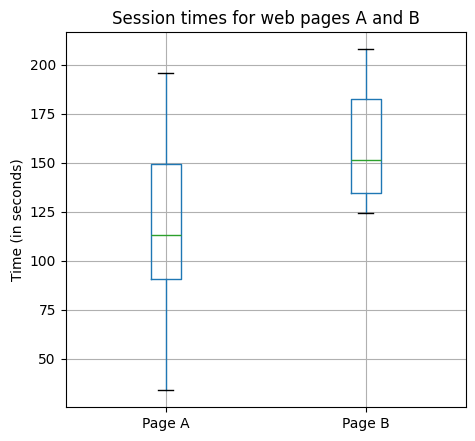

Mean perbedaan waktu sesi (Page B - Page A): 39.6171 detik


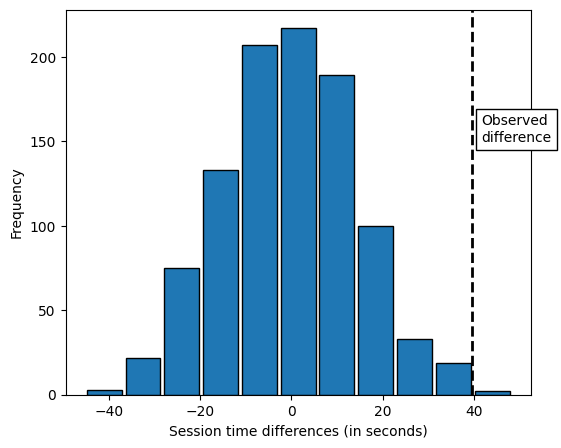

In [2]:
# Simulasi menggunakan data 'session_times' untuk halaman web A dan B
# Membaca data (Jika file tidak ada, kita asumsikan strukturnya berdasarkan buku)
try:
    session_times = pd.read_csv(WEB_PAGE_DATA_CSV)
except FileNotFoundError:
    # Dataset dummy sesuai dengan penjelasan buku (21 Page A, 15 Page B)
    np.random.seed(1)
    session_times = pd.DataFrame({
        'Page': ['Page A']*21 + ['Page B']*15,
        'Time': np.concatenate([np.random.normal(126, 40, 21), np.random.normal(162, 40, 15)])
    })

# Visualisasi Boxplot perbandingan Waktu Sesi (Stickiness)
ax = session_times.boxplot(by='Page', column='Time', figsize=(5, 5))
ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')
plt.title('Session times for web pages A and B')
plt.show()

# Menghitung perbedaan mean yang diobservasi
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
obs_diff = mean_b - mean_a
print(f'Mean perbedaan waktu sesi (Page B - Page A): {obs_diff:.4f} detik')

# Implementasi Fungsi Permutation Test
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]

# Melakukan permutasi sebanyak 1000 kali
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

# Visualisasi Distribusi Permutasi
fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9, edgecolor='black')
ax.axvline(x=obs_diff, color='black', lw=2, linestyle='--')
ax.text(obs_diff + 2, 150, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Session time differences (in seconds)')
ax.set_ylabel('Frequency')
plt.show()

# Menghitung p-value empiris
p_value_perm = np.mean(np.array(perm_diffs) > obs_diff)

---
## 3. Statistical Significance, p-Values, and t-Tests

### Theoretical Explanation
* **p-value:** Probabilitas mendapatkan hasil yang sama ekstremnya (atau lebih ekstrem) dari hasil yang diobservasi, dengan asumsi bahwa hipotesis nol benar (*chance model*)[cite: 13].
* **Alpha ($\alpha$):** Ambang batas penentuan signifikansi (biasanya 5% atau 0.05). Jika p-value $< \alpha$, kita menolak hipotesis nol[cite: 13].
* **Type 1 Error:** Salah menyimpulkan bahwa ada efek nyata padahal hanya kebetulan (menolak hipotesis nol yang benar)[cite: 13].
* **Type 2 Error:** Salah menyimpulkan bahwa efek nyata hanyalah kebetulan (gagal menolak hipotesis nol yang salah)[cite: 13].
* **t-Test:** Uji signifikansi klasik (dikembangkan oleh W.S. Gosset) untuk membandingkan dua rata-rata yang standarisasinya menggunakan *t-distribution*[cite: 13].

In [9]:
# 1. Menghitung p-value untuk data biner (Contoh Konversi Ecommerce)
# Tabel konversi dari buku:
# Price A: 200 konversi, 23539 no-konversi (total 23739)
# Price B: 182 konversi, 22406 no-konversi (total 22588)
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])

# Menggunakan Uji Chi-Square untuk aproksimasi Proporsi Normal
chi2, p_value, df, _ = stats.chi2_contingency(survivors)
print(f'P-value for single sided test (Ecommerce Conversion): {p_value / 2:.4f}')


# 2. t-Test untuk Waktu Sesi (Page A vs Page B)
time_a = session_times[session_times.Page == 'Page A'].Time
time_b = session_times[session_times.Page == 'Page B'].Time

# Menggunakan Welch's t-test (equal_var=False) karena varians mungkin berbeda
res = stats.ttest_ind(time_a, time_b, equal_var=False)
print(f'P-value for single sided t-test (Session Time): {res.pvalue / 2:.4f}')

P-value for single sided test (Ecommerce Conversion): 0.3498
P-value for single sided t-test (Session Time): 0.0013


---
## 4. ANOVA (Analysis of Variance)

### Theoretical Explanation
* **ANOVA:** Digunakan ketika ada lebih dari dua kelompok numerik untuk diuji (misal: A/B/C/D Test)[cite: 13]. Bertujuan mengetahui apakah keseluruhan variasi antar kelompok mencerminkan perbedaan nyata, atau hanya berada dalam rentang peluang acak[cite: 13].
* **F-Statistic:** Rasio dari variabilitas antar rata-rata kelompok (*treatment effect*) dibagi variabilitas di dalam kelompok masing-masing (*residual error*)[cite: 13]. Semakin tinggi rasionya, semakin signifikan hasilnya secara statistik[cite: 13].

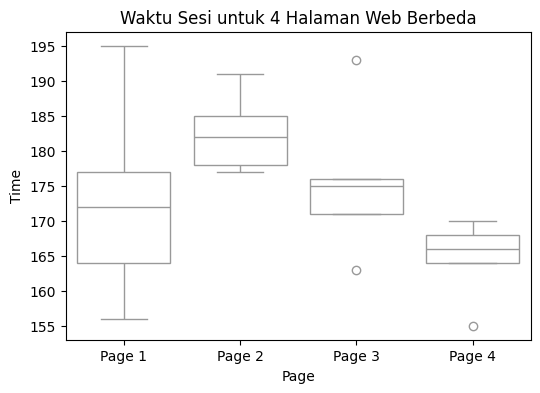

ANOVA Table:


,df,sum_sq,mean_sq,F,PR(>F)
Page,3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN


In [10]:
# Memuat data untuk tes 4 halaman web
try:
    four_sessions = pd.read_csv(FOUR_SESSIONS_CSV)
except FileNotFoundError:
    # Dummy data menyerupai tabel buku
    four_sessions = pd.DataFrame({
        'Page': ['Page 1']*5 + ['Page 2']*5 + ['Page 3']*5 + ['Page 4']*5,
        'Time': [164, 172, 177, 156, 195, 178, 191, 182, 185, 177, 175, 193, 171, 163, 176, 155, 166, 164, 170, 168]
    })

# Boxplot antar kelompok
plt.figure(figsize=(6, 4))
sns.boxplot(x='Page', y='Time', data=four_sessions, color='white')
plt.title('Waktu Sesi untuk 4 Halaman Web Berbeda')
plt.show()

# Menjalankan ANOVA menggunakan statsmodels (Pendekatan Statistik Teoretis OLS)
model = smf.ols('Time ~ Page', data=four_sessions).fit()
aov_table = sm.stats.anova_lm(model)
print("ANOVA Table:")
display(aov_table)

---
## 5. Chi-Square Test

### Theoretical Explanation
* **Chi-Square Test:** Sering digunakan untuk menguji himpunan data jumlah (*count data*) untuk melihat kecocokannya dengan suatu sebaran yang diekspektasikan (*goodness-of-fit test*)[cite: 13].
* **Chi-Square Statistic:** Mengukur jarak pergeseran dari apa yang diekspektasikan berdasarkan model null (hipotesis nol berupa variabel bersifat saling independen)[cite: 13]:
  $$X^2 = \sum \frac{(Observed - Expected)^2}{Expected}$$
* Sering digunakan untuk menyeleksi atau mengevaluasi tabel kontingensi (misal: apakah performa 3 judul berita yang berbeda benar-benar berbeda, atau sebatas variasi acak)[cite: 13].

In [11]:
# Data hasil klik untuk 3 Headline (dari buku Table 3-4)
# Baris 1: Click, Baris 2: No-click
clicks_data = pd.DataFrame([
    [14, 8, 12],
    [986, 992, 988]
], columns=['Headline A', 'Headline B', 'Headline C'], index=['Click', 'No-click'])

print("Tabel Hasil Eksperimen Web untuk 3 Headline:")
display(clicks_data)

# Menerapkan Uji Chi-Square dari scipy.stats
chisq, pvalue, df, expected = stats.chi2_contingency(clicks_data)

print(f'Observed Chi-Square Statistic: {chisq:.4f}')
print(f'P-value: {pvalue:.4f}')
print(f'Degrees of Freedom: {df}')

print("\nExpected Counts jika asumsi Null Hypothesis (Tidak ada perbedaan performa Headline) Benar:")
expected_df = pd.DataFrame(expected, columns=clicks_data.columns, index=clicks_data.index)
display(expected_df)

Tabel Hasil Eksperimen Web untuk 3 Headline:


,Headline A,Headline B,Headline C
Click,14,8,12
No-click,986,992,988


Observed Chi-Square Statistic: 1.6659
P-value: 0.4348
Degrees of Freedom: 2

Expected Counts jika asumsi Null Hypothesis (Tidak ada perbedaan performa Headline) Benar:


,Headline A,Headline B,Headline C
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


---
## 6. Multi-Arm Bandit & Power and Sample Size

### Theoretical Explanation
* **Multi-Arm Bandit:** Algoritma optimasi eksperimen berkelanjutan, di mana frekuensi kelompok yang kinerjanya lebih buruk secara bertahap dikurangi, dan *traffic* dialihkan ke kelompok yang berkinerja unggul (*epsilon-greedy algorithm*)[cite: 13].
* **Power and Sample Size:** Cara menentukan berapa banyak data yang harus dikumpulkan dalam eksperimen (misal: A/B Test)[cite: 13]. Untuk menentukan ini, 3 parameter perlu disiapkan:
  1. **Effect Size:** Ukuran minimal perubahan yang ingin dideteksi (misal: "kenaikan 10% klik")[cite: 13].
  2. **Significance Level (Alpha):** Ambang batas signifikansi pengujian (misal: 0.05)[cite: 13].
  3. **Power:** Probabilitas keberhasilan mendeteksi efek tersebut (misal: 0.8 atau 80%)[cite: 13].

In [13]:
# Kalkulasi Ukuran Sampel menggunakan statsmodels
import statsmodels.stats.api as sm_stats

# Skenario: Konversi awal 1.1% (0.011), kita ingin mendeteksi peningkatan sebesar 10%
# Sehingga target konversi adalah 1.21% (0.0121)

# Menghitung effect size berdasarkan dua proporsi
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)

# Menginisiasi objek kalkulator Power
analysis = sm.stats.TTestIndPower()

# Menyelesaikan kalkulasi sampel berdasarkan effect size, alpha=0.05, dan power=0.8
result = analysis.solve_power(effect_size=effect_size,
                              alpha=0.05,
                              power=0.8,
                              alternative='larger')

print(f'Ukuran Sampel (Sample Size) yang dibutuhkan per kelompok percobaan:')
print(f'{result:,.0f} impresi')

Ukuran Sampel (Sample Size) yang dibutuhkan per kelompok percobaan:
116,602 impresi
